<a href="https://colab.research.google.com/github/Sontakkepratham/phone-pe/blob/main/phone_pe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas sqlalchemy psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 44.2 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/PhonePe/pulse.git

Cloning into 'pulse'...
remote: Enumerating objects: 17904, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 17904 (delta 19), reused 17 (delta 17), pack-reused 17855 (from 2)
Receiving objects: 100% (17904/17904), 26.13 MiB | 16.84 MiB/s, done.
Resolving deltas: 100% (8723/8723), done.
Updating files: 100% (9029/9029), done.


In [3]:
import json

with open("/content/pulse/data/aggregated/transaction/country/india/state/andaman-&-nicobar-islands/2018/1.json") as f:
  data = json.load(f)

data

{'success': True,
 'code': 'SUCCESS',
 'data': {'from': 1514745000000,
  'to': 1522175400000,
  'transactionData': [{'name': 'Recharge & bill payments',
    'paymentInstruments': [{'type': 'TOTAL',
      'count': 4200,
      'amount': 1845307.4673655091}]},
   {'name': 'Peer-to-peer payments',
    'paymentInstruments': [{'type': 'TOTAL',
      'count': 1871,
      'amount': 12138655.299749982}]},
   {'name': 'Merchant payments',
    'paymentInstruments': [{'type': 'TOTAL',
      'count': 298,
      'amount': 452507.168646613}]},
   {'name': 'Financial Services',
    'paymentInstruments': [{'type': 'TOTAL',
      'count': 33,
      'amount': 10601.419933464953}]},
   {'name': 'Others',
    'paymentInstruments': [{'type': 'TOTAL',
      'count': 256,
      'amount': 184689.8662902223}]}]},
 'responseTimestamp': 1630501487199}

In [4]:
import os
import json
import pandas as pd

path = "/content/pulse/data/aggregated/transaction/country/india/state/"

data_list = []

for state in os.listdir(path):
    state_path = path + state + "/"

    for year in os.listdir(state_path):
        year_path = state_path + year + "/"

        for file in os.listdir(year_path):
            if file.endswith(".json"):

                with open(year_path + file) as f:
                    data = json.load(f)

                    for item in data["data"]["transactionData"]:
                        data_list.append({
                            "state": state,
                            "year": int(year),
                            "quarter": int(file.strip(".json")),
                            "transaction_type": item["name"],
                            "transaction_count": item["paymentInstruments"][0]["count"],
                            "transaction_amount": item["paymentInstruments"][0]["amount"]
                        })

df_transaction = pd.DataFrame(data_list)
df_transaction.head()

,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,delhi,2023,4,Merchant payments,381250463,1.687665e+11
1,delhi,2023,4,Peer-to-peer payments,185276322,5.881312e+11
2,delhi,2023,4,Recharge & bill payments,30903762,4.188944e+10
3,delhi,2023,4,Financial Services,317005,5.013539e+08
4,delhi,2023,4,Others,403194,3.612766e+08


In [5]:
df_transaction["state"] = df_transaction["state"].str.replace("-", " ").str.title()
df_transaction = df_transaction.dropna()

In [6]:
df_transaction.info()
df_transaction.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   state               5034 non-null   object 
 1   year                5034 non-null   int64  
 2   quarter             5034 non-null   int64  
 3   transaction_type    5034 non-null   object 
 4   transaction_count   5034 non-null   int64  
 5   transaction_amount  5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB


,year,quarter,transaction_count,transaction_amount
count,5034.000000,5034.000000,5.034000e+03,5.034000e+03
mean,2021.002582,2.500795,4.673902e+07,6.863772e+10
std,1.999849,1.118145,1.690968e+08,2.685200e+11
min,2018.000000,1.000000,2.000000e+00,3.439721e+01
25%,2019.000000,2.000000,5.808950e+04,3.993888e+07
50%,2021.000000,3.000000,5.158310e+05,4.394139e+08
75%,2023.000000,4.000000,1.166629e+07,1.102822e+10
max,2024.000000,4.000000,2.393918e+09,3.095666e+12


In [7]:
df_transaction.to_csv("aggregated_transaction.csv", index=False)

In [9]:
import os
import json
import pandas as pd

path = "/content/pulse/data/aggregated/user/country/india/state/"

user_data = []

for state in os.listdir(path):
    state_path = path + state + "/"

    for year in os.listdir(state_path):
        year_path = state_path + year + "/"

        for file in os.listdir(year_path):
            if file.endswith(".json"):
                with open(year_path + file) as f:
                    data = json.load(f)

                    try:
                        for item in data["data"]["usersByDevice"]:
                            user_data.append({
                                "state": state,
                                "year": int(year),
                                "quarter": int(file.strip(".json")),
                                "brand": item["brand"],
                                "user_count": item["count"]
                            })
                    except:
                        pass

df_user = pd.DataFrame(user_data)
df_user.head()

,state,year,quarter,brand,user_count
0,delhi,2019,4,Xiaomi,1872284
1,delhi,2019,4,Samsung,1394404
2,delhi,2019,4,Vivo,1114120
3,delhi,2019,4,Oppo,825921
4,delhi,2019,4,Apple,414754


In [10]:
path = "/content/pulse/data/map/transaction/hover/country/india/state/"

map_trans = []

for state in os.listdir(path):
    state_path = path + state + "/"

    for year in os.listdir(state_path):
        year_path = state_path + year + "/"

        for file in os.listdir(year_path):
            if file.endswith(".json"):
                with open(year_path + file) as f:
                    data = json.load(f)

                    for item in data["data"]["hoverDataList"]:
                        map_trans.append({
                            "state": state,
                            "district": item["name"],
                            "year": int(year),
                            "quarter": int(file.strip(".json")),
                            "transaction_count": item["metric"][0]["count"],
                            "transaction_amount": item["metric"][0]["amount"]
                        })

df_map_trans = pd.DataFrame(map_trans)
df_map_trans.head()

,state,district,year,quarter,transaction_count,transaction_amount
0,delhi,south district,2023,4,47263751,4.921779e+10
1,delhi,central district,2023,4,73391621,1.086860e+11
2,delhi,new delhi district,2023,4,70788153,7.772537e+10
3,delhi,west district,2023,4,77741144,1.141642e+11
4,delhi,south west district,2023,4,45782050,5.937327e+10


In [11]:
path = "/content/pulse/data/map/user/hover/country/india/state/"

map_user = []

for state in os.listdir(path):
    state_path = path + state + "/"

    for year in os.listdir(state_path):
        year_path = state_path + year + "/"

        for file in os.listdir(year_path):
            if file.endswith(".json"):
                with open(year_path + file) as f:
                    data = json.load(f)

                    for district, values in data["data"]["hoverData"].items():
                        map_user.append({
                            "state": state,
                            "district": district,
                            "year": int(year),
                            "quarter": int(file.strip(".json")),
                            "user_count": values["registeredUsers"]
                        })

df_map_user = pd.DataFrame(map_user)
df_map_user.head()

,state,district,year,quarter,user_count
0,delhi,south district,2023,4,1296849
1,delhi,central district,2023,4,1815323
2,delhi,new delhi district,2023,4,1803952
3,delhi,west district,2023,4,2732926
4,delhi,south west district,2023,4,1484762


In [12]:
path = "/content/pulse/data/top/transaction/country/india/state/"

top_trans = []

for state in os.listdir(path):
    state_path = path + state + "/"

    for year in os.listdir(state_path):
        year_path = state_path + year + "/"

        for file in os.listdir(year_path):
            if file.endswith(".json"):
                with open(year_path + file) as f:
                    data = json.load(f)

                    for item in data["data"]["districts"]:
                        top_trans.append({
                            "state": state,
                            "year": int(year),
                            "quarter": int(file.strip(".json")),
                            "district": item["entityName"],
                            "transaction_count": item["metric"]["count"],
                            "transaction_amount": item["metric"]["amount"]
                        })

df_top_trans = pd.DataFrame(top_trans)
df_top_trans.head()

,state,year,quarter,district,transaction_count,transaction_amount
0,delhi,2023,4,south east delhi,81901206,9.221125e+10
1,delhi,2023,4,west,77741144,1.141642e+11
2,delhi,2023,4,central delhi,73391621,1.086860e+11
3,delhi,2023,4,new delhi,70788153,7.772537e+10
4,delhi,2023,4,north west,49542115,7.462120e+10


In [13]:
def clean_state(df):
    df["state"] = df["state"].str.replace("-", " ").str.title()
    return df

df_user = clean_state(df_user)
df_map_trans = clean_state(df_map_trans)
df_map_user = clean_state(df_map_user)
df_top_trans = clean_state(df_top_trans)

In [14]:
df_user.to_csv("aggregated_user.csv", index=False)
df_map_trans.to_csv("map_transaction.csv", index=False)
df_map_user.to_csv("map_user.csv", index=False)
df_top_trans.to_csv("top_transaction.csv", index=False)

In [15]:
import sqlite3

conn = sqlite3.connect("phonepe.db")

In [16]:
df_transaction.to_sql("aggregated_transaction", conn, if_exists="replace", index=False)
df_user.to_sql("aggregated_user", conn, if_exists="replace", index=False)
df_map_trans.to_sql("map_transaction", conn, if_exists="replace", index=False)
df_map_user.to_sql("map_user", conn, if_exists="replace", index=False)
df_top_trans.to_sql("top_transaction", conn, if_exists="replace", index=False)

8296

In [17]:
pd.read_sql("SELECT * FROM aggregated_transaction LIMIT 5", conn)

,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,Delhi,2023,4,Merchant payments,381250463,1.687665e+11
1,Delhi,2023,4,Peer-to-peer payments,185276322,5.881312e+11
2,Delhi,2023,4,Recharge & bill payments,30903762,4.188944e+10
3,Delhi,2023,4,Financial Services,317005,5.013539e+08
4,Delhi,2023,4,Others,403194,3.612766e+08


In [18]:
query = """
SELECT state, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY state
ORDER BY total_amount DESC
LIMIT 10;
"""

df_top_states = pd.read_sql(query, conn)
df_top_states

,state,total_amount
0,Telangana,4.165596e+13
1,Karnataka,4.067872e+13
2,Maharashtra,4.037420e+13
3,Andhra Pradesh,3.466908e+13
4,Uttar Pradesh,2.688521e+13
5,Rajasthan,2.634324e+13
6,Madhya Pradesh,1.912528e+13
7,Bihar,1.790135e+13
8,West Bengal,1.558416e+13
9,Odisha,1.226398e+13


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

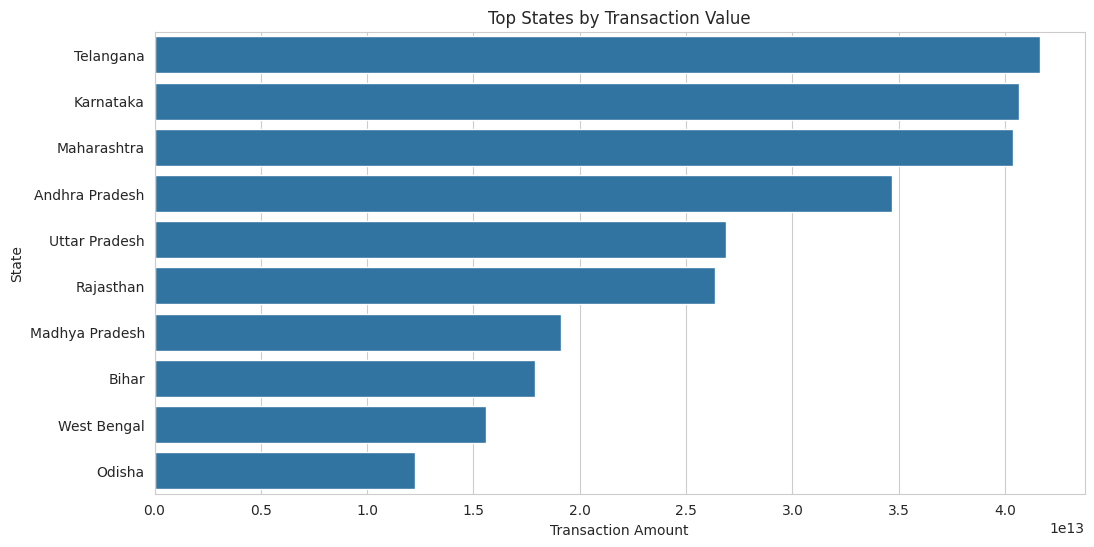

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_top_states, x="total_amount", y="state")
plt.title("Top States by Transaction Value")
plt.xlabel("Transaction Amount")
plt.ylabel("State")
plt.show()

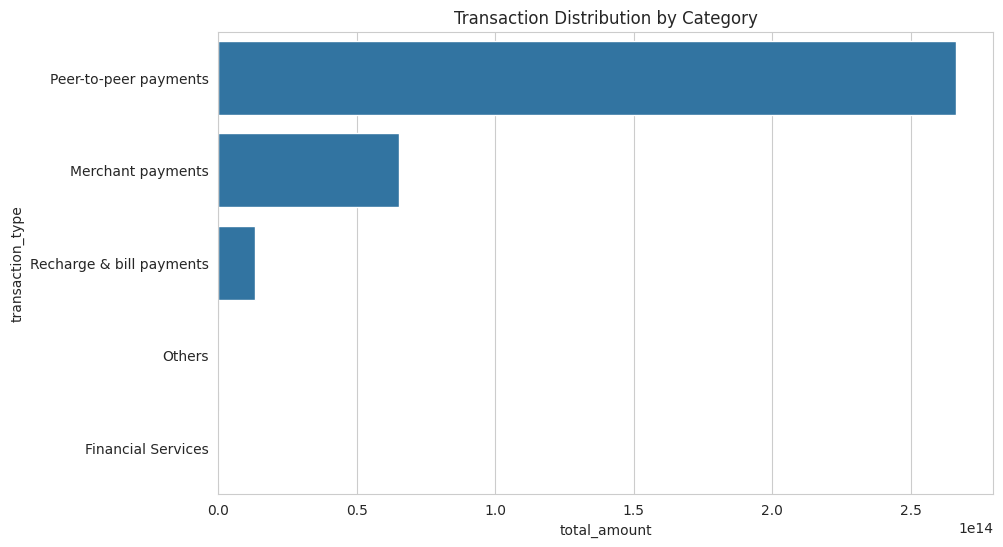

In [21]:
query = """
SELECT transaction_type, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY transaction_type
ORDER BY total_amount DESC;
"""

df_category = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))
sns.barplot(data=df_category, x="total_amount", y="transaction_type")
plt.title("Transaction Distribution by Category")
plt.show()

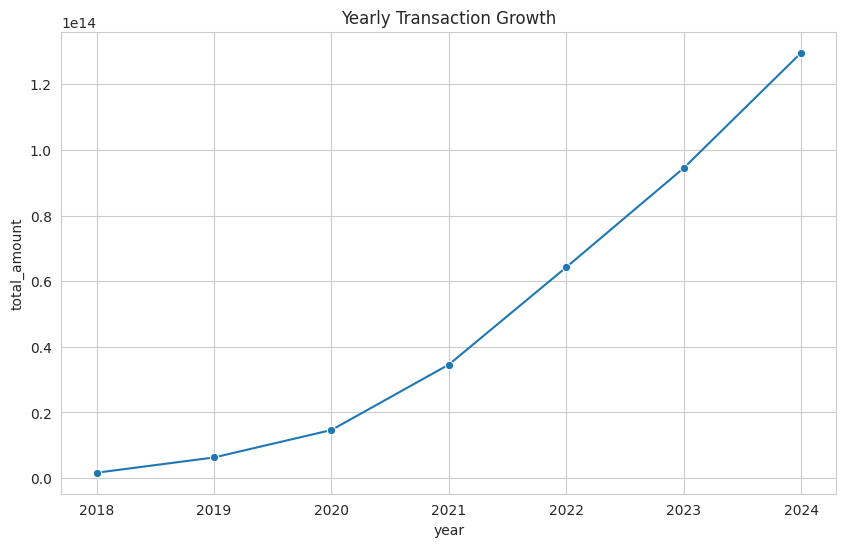

In [22]:
query = """
SELECT year, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY year
ORDER BY year;
"""

df_year = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))
sns.lineplot(data=df_year, x="year", y="total_amount", marker="o")
plt.title("Yearly Transaction Growth")
plt.show()

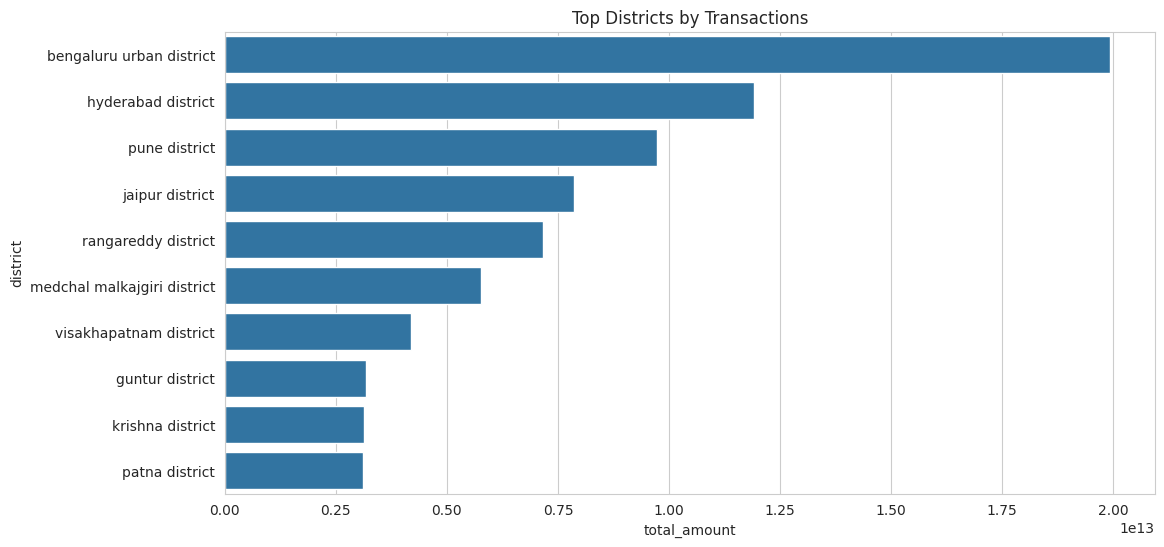

In [23]:
query = """
SELECT district, SUM(transaction_amount) AS total_amount
FROM map_transaction
GROUP BY district
ORDER BY total_amount DESC
LIMIT 10;
"""

df_district = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(data=df_district, x="total_amount", y="district")
plt.title("Top Districts by Transactions")
plt.show()

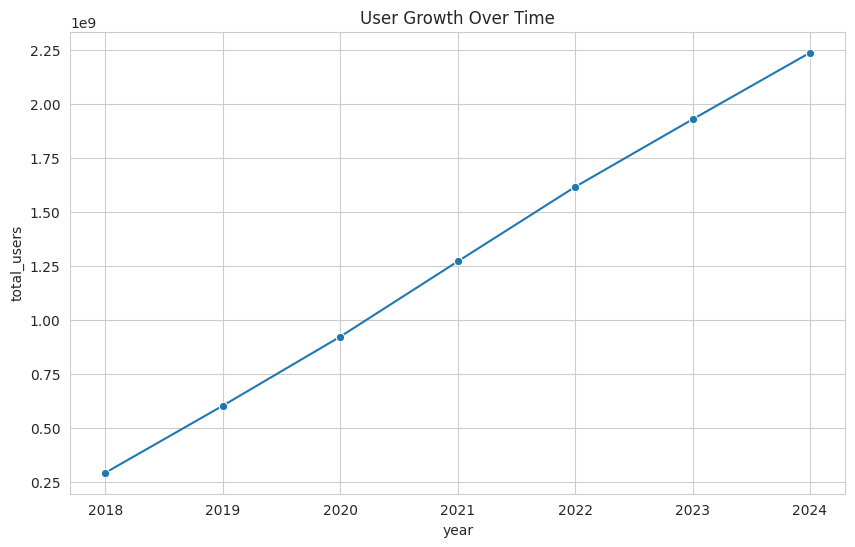

In [24]:
query = """
SELECT year, SUM(user_count) AS total_users
FROM map_user
GROUP BY year
ORDER BY year;
"""

df_users = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))
sns.lineplot(data=df_users, x="year", y="total_users", marker="o")
plt.title("User Growth Over Time")
plt.show()

In [25]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.5 MB/s eta 0:00:00


In [26]:
%%writefile app.py

Writing app.py


In [27]:
import streamlit as st
import pandas as pd
import sqlite3

# DB Connection
conn = sqlite3.connect("phonepe.db")

st.set_page_config(page_title="PhonePe Insights", layout="wide")

st.title("📊 PhonePe Transaction Insights Dashboard")

# Sidebar
st.sidebar.header("Filters")

year = st.sidebar.selectbox(
    "Select Year",
    pd.read_sql("SELECT DISTINCT year FROM aggregated_transaction", conn)["year"]
)

# ==============================
# SECTION 1: TOP STATES
# ==============================

st.subheader("🏆 Top States by Transaction Value")

query = f"""
SELECT state, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
WHERE year = {year}
GROUP BY state
ORDER BY total_amount DESC
LIMIT 10;
"""

df_top_states = pd.read_sql(query, conn)

st.bar_chart(df_top_states.set_index("state"))

# ==============================
# SECTION 2: CATEGORY DISTRIBUTION
# ==============================

st.subheader("💳 Transaction Category Distribution")

query = f"""
SELECT transaction_type, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
WHERE year = {year}
GROUP BY transaction_type
ORDER BY total_amount DESC;
"""

df_category = pd.read_sql(query, conn)

st.bar_chart(df_category.set_index("transaction_type"))

# ==============================
# SECTION 3: YEARLY TREND
# ==============================

st.subheader("📈 Yearly Growth")

query = """
SELECT year, SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
GROUP BY year
ORDER BY year;
"""

df_year = pd.read_sql(query, conn)

st.line_chart(df_year.set_index("year"))

# ==============================
# SECTION 4: TOP DISTRICTS
# ==============================

st.subheader("📍 Top Districts")

query = f"""
SELECT district, SUM(transaction_amount) AS total_amount
FROM map_transaction
WHERE year = {year}
GROUP BY district
ORDER BY total_amount DESC
LIMIT 10;
"""

df_district = pd.read_sql(query, conn)

st.bar_chart(df_district.set_index("district"))

# ==============================
# SECTION 5: USER GROWTH
# ==============================

st.subheader("👥 User Growth")

query = """
SELECT year, SUM(user_count) AS total_users
FROM map_user
GROUP BY year
ORDER BY year;
"""

df_users = pd.read_sql(query, conn)

st.line_chart(df_users.set_index("year"))

2026-03-25 06:30:20.914 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 06:30:20.916 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 06:30:21.303 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-25 06:30:21.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 06:30:21.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 06:30:21.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 06:30:21.308 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

In [28]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.56.242.200:8501

  Stopping...
^C
